# CAMM Hackathon 13: Two Previous Problems Revisited with Agents

In this notebook we revisit two problems from earlier CAMM hackathons and suggest solving them again, but this time with an **agentic approach**.

## What is an agent?

For this hackathon, an agent is an LLM-based system that can **plan**, **use tools**, **inspect intermediate results**, and **iterate** toward a goal instead of producing only one direct answer.

A simple agent loop is:

1. observe the current state
2. decide what to do next
3. call a tool or run code
4. evaluate the result
5. revise the plan if needed

## Good starting references

- Anthropic, [Building Effective Agents](https://www.anthropic.com/engineering/building-effective-agents)
- OpenAI, [A Practical Guide to Building AI Agents](https://openai.com/business/guides-and-resources/a-practical-guide-to-building-ai-agents/)


In [1]:
!pip install gpytorch


In [2]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line


## Problem 1: STEM Image Restoration

This problem comes from [**CAMM Hackathon #10**](https://github.com/kbarakati/camm_hackathon/blob/k4my4r/docs/day_10_27032026/CAMM_hackaton_10_Image_Restoration.ipynb).

**Task:** given a 2D microscopy intensity image and a binary loss mask, reconstruct the missing regions and estimate uncertainty.


In [3]:
image_files = {
    "graphene_2.h5": "14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs",
    "HAADF_21.h5": "1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN",
}

for filename, file_id in image_files.items():
    if not Path(filename).exists():
        !gdown {file_id} -O "{filename}"
    else:
        print(f"Using existing file: {filename}")


Using existing file: graphene_2.h5
Using existing file: HAADF_21.h5


In [4]:
import json


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)


def _load_item(obj):
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}
        if all(k.isdigit() for k in keys):
            return [_load_item(obj[k]) for k in sorted(keys, key=lambda x: int(x))]
        out = {k: _load_item(obj[k]) for k in keys}
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None
        return out

    if isinstance(obj, h5py.Dataset):
        data = obj[()]
        if np.isscalar(data):
            return data
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except Exception:
                return data.decode()
        if getattr(data, "dtype", None) is not None and data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except Exception:
                return [x.decode() for x in data]
        return data

    raise ValueError(f"Unknown HDF5 object type: {type(obj)}")


def mask_below_line(im, frac=0.6, above=True):
    h, w = im.shape
    row = int(frac * h)
    mask = np.zeros((h, w), dtype=bool)
    mask[:row, :] = True if above else False
    mask[row:, :] = False if above else True
    return mask


def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=0):
    rng = np.random.default_rng(seed)
    h, w = im.shape
    mask = np.zeros((h, w), dtype=bool)
    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        ort = rng.choice(orientations) if orientation == "mixed" else orientation
        if ort == "horizontal":
            mask[rng.integers(0, h), :] = True
        elif ort == "vertical":
            mask[:, rng.integers(0, w)] = True
        else:
            r0, c0 = rng.integers(0, h), rng.integers(0, w)
            r1, c1 = rng.integers(0, h), rng.integers(0, w)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < h) & (cc >= 0) & (cc < w)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        mask = binary_dilation(mask, structure=np.ones((thickness, thickness), dtype=bool))
    return ~mask


In [5]:
data = load_hdf5_to_dict("graphene_2.h5")
data_more = load_hdf5_to_dict("HAADF_21.h5")

im0 = data["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"][:1000, :1000]
im1 = data["Measurement_001"]["Channel_000"]["HAADF"]["HAADF"][:1000, :1000]
im2 = data["Measurement_001"]["Channel_000"]["HAADF"]["HAADF"][:1000, -1000:]
im3 = data_more["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"]

ims = [im0, im1, im2, im3]


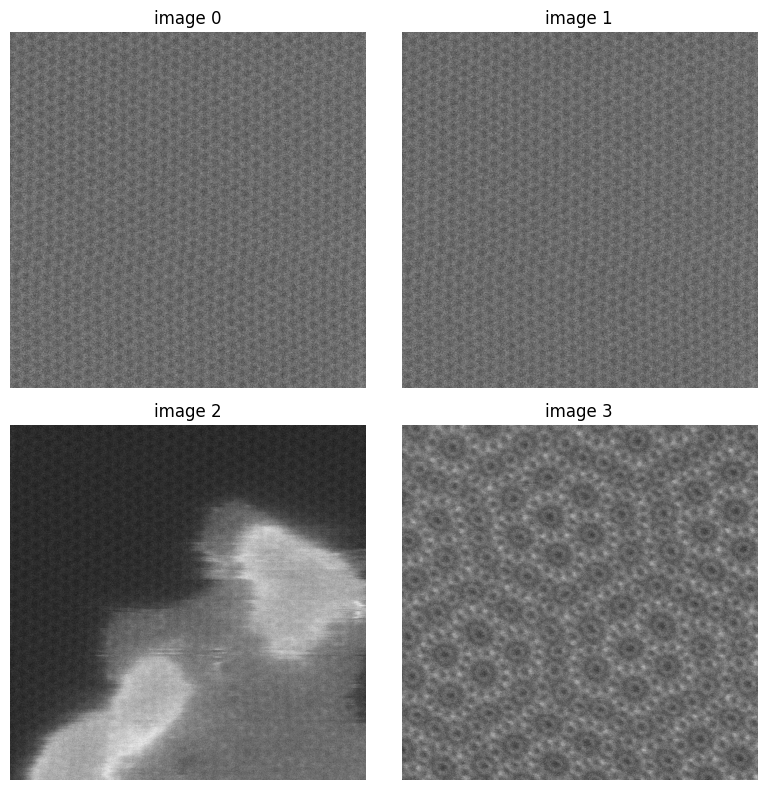

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(ims[i], cmap="gray")
    ax.set_title(f"image {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()


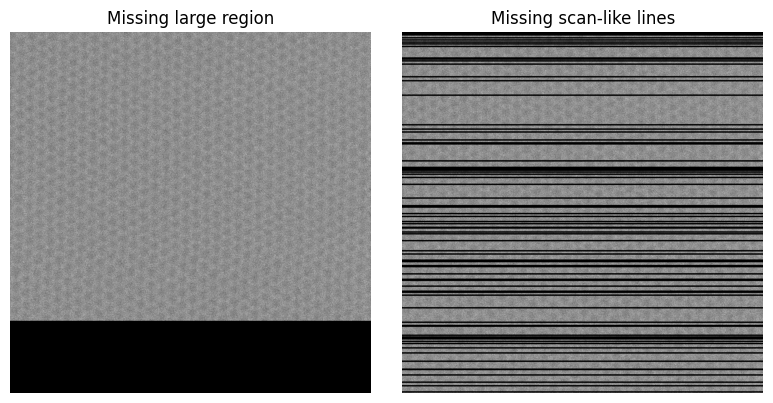

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(mask_below_line(im0, frac=0.8) * im0, cmap="gray")
ax[0].set_title("Missing large region")
ax[0].axis("off")

ax[1].imshow(mask_lines(im0, seed=0) * im0, cmap="gray")
ax[1].set_title("Missing scan-like lines")
ax[1].axis("off")
plt.tight_layout()
plt.show()


### Can we design an agent which will design and execute uncertanty aware image reconstruction framework?

## Problem 2: Active Experimental Design under Noise and Budget Constraints

This problem comes from [**CAMM Hackathon #11**](https://github.com/kbarakati/camm_hackathon/blob/k4my4r/docs/day_11_10042026/CAMM_Hackaton_11.ipynb).

**Task:** design a strategy that decides **where to measure**, **in what order**, and **for how long**, while accounting for measurement noise, limited budget, and movement cost.


### Minimal starter setup

The general setup cell above already installs the required packages. The cells below give a lightweight starting point for testing an adaptive measurement strategy.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch


In [9]:
# Example target functions for testing your strategy

def unimodal(x):
    return 1.2 * np.exp(-0.5 * ((x - 2.3) / 0.7) ** 2) + 0.1


def oscillatory(x):
    return 0.55 + 0.15 * np.sin(1.8 * x) + 0.08 * np.cos(6.0 * x)

def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    return res/40


def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 7)**2 + 0.45 * x

    return res/10

def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x - 2.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.08**2))
    )
    return res


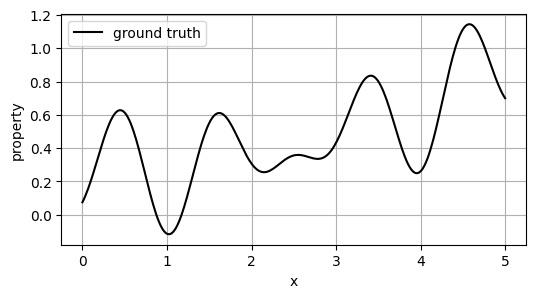

In [10]:
x_grid = np.linspace(0, 5, 300)
f_true = multimodal

plt.figure(figsize=(6, 3))
plt.plot(x_grid, f_true(x_grid), 'k', label='ground truth')
plt.xlabel('x')
plt.ylabel('property')
plt.grid()
plt.legend()
plt.show()


In [11]:

#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [12]:
# Simple budget accounting example
budget_total = 12.0
travel_weight = 0.15

# Example move from x=1.0 to x=3.5 with acquisition time 0.8
x_prev = 1.0
x_next = 3.5
acq_time = 0.8

travel_cost = travel_weight * abs(x_next - x_prev)
step_cost = acq_time + travel_cost
print('Example step cost:', round(step_cost, 3))
print('Remaining budget after step:', round(budget_total - step_cost, 3))


Example step cost: 1.175
Remaining budget after step: 10.825


In [13]:

#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

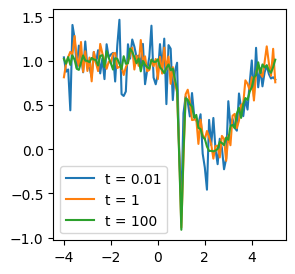

In [14]:

#@title example: grid measurements with different acqusition time

x = np.linspace(-4,5, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]


sim_decay = MeasurementSimulator(
    ground_truth_model=broad_narrow,
    noise_model=noise_decay_floor,
    rng=2,
)


fig, ax = plt.subplots(figsize=(3,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax.plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')

ax.legend()

#### Can an agentic approach be useful for planning such experimental campaigns?